# Metrics + Data Viz for GPT4o LID

In [1]:
#Necessary imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

In [15]:
lid_df = pd.read_csv("../output/gpt_lid_2026-05-11_22-41-37.csv")
lid_df.head()

,Unnamed: 0,doc_id,sent_id,tok_id,token,lid,borrowed_suffix,ner,gpt_langid
0,0,post_0001,1,0,yabancı,TR,NaN,NaN,TR
1,1,post_0001,1,1,bir,TR,NaN,NaN,TR
2,2,post_0001,1,2,hocamızın,TR,NaN,NaN,TR
3,3,post_0001,1,3,yarı,TR,NaN,NaN,TR
4,4,post_0001,1,4,şaka,TR,NaN,NaN,TR


In [4]:
lid_df["gpt_langid"].value_counts()

gpt_langid
TR           3217
AMBIGUOUS     811
EN            623
MIXED          95
NE             87
OTHER          12
Name: count, dtype: int64

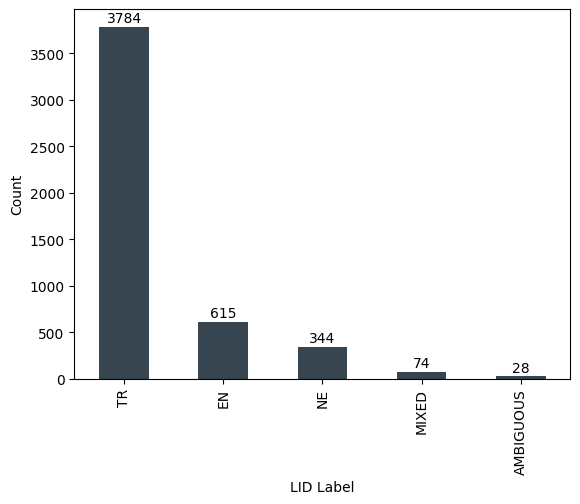

In [45]:
ax = lid_df['lid'].value_counts().plot(kind='bar', color='#36454F')
ax.bar_label(ax.containers[0], padding=1)
plt.xlabel('LID Label')
plt.ylabel('Count')
plt.show()

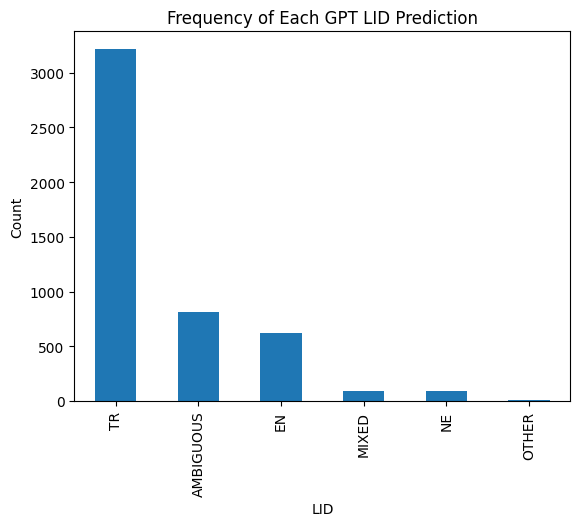

In [16]:
lid_df['gpt_langid'].value_counts().plot(kind='bar')
plt.title('Frequency of Each GPT LID Prediction')
plt.xlabel('LID')
plt.ylabel('Count')
plt.show()

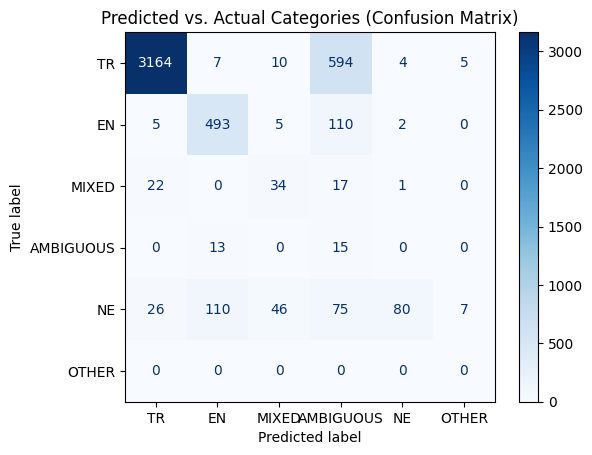

In [17]:
#Confusion matrix
cm = confusion_matrix(lid_df['lid'], lid_df['gpt_langid'], labels=["TR", "EN", "MIXED", "AMBIGUOUS", "NE", "OTHER", "UNK"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["TR", "EN", "MIXED", "AMBIGUOUS", "NE", "OTHER", "UNK"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Predicted vs. Actual Categories (Confusion Matrix)")
plt.show()

In [8]:
#Macro F1
macro_f1 = f1_score(lid_df["lid"], lid_df["gpt_langid"], average='macro')
print(f"Overall Macro F1 Score: {macro_f1:.4f}\n")

Overall Macro F1 Score: 0.4183



In [9]:
#F1 Per Class
f1_per_class = f1_score(lid_df["lid"], lid_df["gpt_langid"], average=None)
print(f"F1 Score per Class: {f1_per_class}\n")

F1 Score per Class: [0.03575685 0.79644588 0.40236686 0.3712297  0.         0.90387088]



In [10]:
#Full Classification Report
print("Classification Report:")
print(classification_report(lid_df["lid"], lid_df["gpt_langid"]))

Classification Report:
              precision    recall  f1-score   support

   AMBIGUOUS       0.02      0.54      0.04        28
          EN       0.79      0.80      0.80       615
       MIXED       0.36      0.46      0.40        74
          NE       0.92      0.23      0.37       344
       OTHER       0.00      0.00      0.00         0
          TR       0.98      0.84      0.90      3784

    accuracy                           0.78      4845
   macro avg       0.51      0.48      0.42      4845
weighted avg       0.94      0.78      0.84      4845



/Users/ilaydadogan/miniconda3/envs/eksiproject/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/ilaydadogan/miniconda3/envs/eksiproject/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/ilaydadogan/miniconda3/envs/eksiproject/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.

In [12]:
mismatched_rows = lid_df[lid_df['lid'] != lid_df['gpt_langid']]

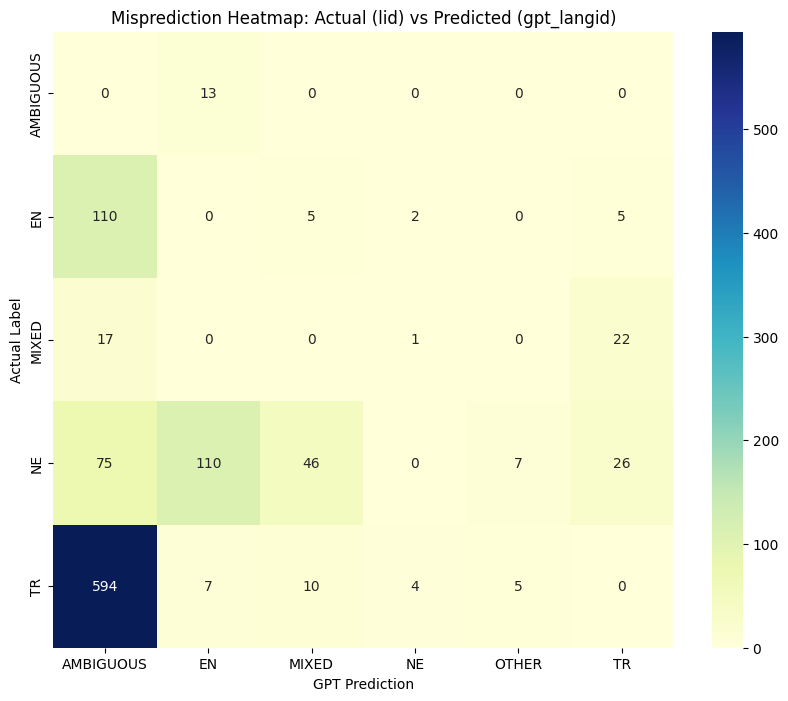

In [13]:
#Mismatched rows CM
cm = pd.crosstab(mismatched_rows['lid'], mismatched_rows['gpt_langid'])
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Misprediction Heatmap: Actual (lid) vs Predicted (gpt_langid)')
plt.ylabel('Actual Label')
plt.xlabel('GPT Prediction')
plt.show()

In [14]:
mismatched_rows[mismatched_rows["lid"] == "MIXED"]

,Unnamed: 0,doc_id,sent_id,tok_id,token,lid,borrowed_suffix,ner,gpt_langid
389,389,post_0016,1,5,conlarindan,MIXED,MIXED,NaN,TR
464,464,post_0019,4,0,lgbti,MIXED,MIXED,NaN,AMBIGUOUS
553,553,post_0022,3,0,turntablea,MIXED,MIXED,NaN,AMBIGUOUS
558,558,post_0022,3,5,mixler,MIXED,MIXED,NaN,TR
570,570,post_0022,3,17,djim,MIXED,MIXED,NaN,AMBIGUOUS
584,584,post_0022,4,10,djlik,MIXED,MIXED,NaN,AMBIGUOUS
670,670,post_0027,4,3,mottom,MIXED,MIXED,NaN,AMBIGUOUS
843,843,post_0031,1,4,veganlar,MIXED,MIXED,NaN,TR
895,895,post_0033,1,1,trendle,MIXED,MIXED,NaN,AMBIGUOUS
1174,1174,post_002,1,42,toollar,MIXED,MIXED,O,AMBIGUOUS
